In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('agg')
import matplotlib.pyplot as plt
import os
# from tqdm.notebook import  tqdm
from tqdm import  tqdm
import talib
import datetime
import math
import  mplfinance as mpf

import sys
sys.path.append('../../DataSource/同花顺')
import datasource
sys.path.append('../..')
import Utils
# 这个是筛选多少天上涨多少的，
codes = datasource.get_codes()
print(f'股票数量:{len(codes)},第一支股票:{codes[0]}')
code = codes[0]
dt = datasource.getData(code)
dt.head()

股票数量:6974,第一支股票:000001


,Id,Code,Date,Open,High,Low,Close,Amount,Volume
0,1,000001,2014-01-02,12.12,12.30,12.05,12.23,596223740.0,48991089.0
1,2,000001,2014-01-03,12.15,12.16,11.78,11.93,656631300.0,55111484.0
2,3,000001,2014-01-06,11.89,12.00,11.50,11.67,679280380.0,58211823.0
3,4,000001,2014-01-07,11.53,11.76,11.51,11.63,393977580.0,33840749.0
4,5,000001,2014-01-08,11.64,11.95,11.53,11.76,538436170.0,45776816.0


In [8]:
dt['atr'] = talib.ATR(dt['High'], dt['Low'], dt['Close'], timeperiod=14)
dt.head()

,Id,Code,Date,Open,High,Low,Close,Amount,Volume,atr
0,1,000001,2014-01-02,12.12,12.30,12.05,12.23,596223740.0,48991089.0,NaN
1,2,000001,2014-01-03,12.15,12.16,11.78,11.93,656631300.0,55111484.0,NaN
2,3,000001,2014-01-06,11.89,12.00,11.50,11.67,679280380.0,58211823.0,NaN
3,4,000001,2014-01-07,11.53,11.76,11.51,11.63,393977580.0,33840749.0,NaN
4,5,000001,2014-01-08,11.64,11.95,11.53,11.76,538436170.0,45776816.0,NaN


In [15]:
# 我想计算今天收盘价相比较昨天收盘价的涨幅对atr的比例
dt['preClose']= dt['Close'].shift()
dt['preAtr'] = dt['atr'].shift()
dt['rate']= abs(dt['Close']-dt['preClose'])/dt['preAtr']*100 # 这里要用绝对值
dt = dt.dropna()

In [16]:
dt['rate'].mean() # 可以看到平均涨幅是平均数

np.float64(52.53839144760267)

In [17]:
df_rate_int = dt['rate'].astype(int)

In [21]:
from collections import Counter
counts = Counter(df_rate_int.tolist())
counts

Counter({0: 79,
         7: 63,
         12: 51,
         6: 49,
         4: 46,
         10: 45,
         14: 44,
         20: 43,
         13: 42,
         18: 41,
         5: 41,
         19: 40,
         39: 39,
         2: 39,
         25: 38,
         8: 38,
         26: 38,
         35: 37,
         9: 37,
         11: 36,
         23: 35,
         27: 34,
         17: 34,
         33: 33,
         28: 33,
         24: 32,
         15: 32,
         31: 31,
         43: 31,
         37: 31,
         32: 30,
         42: 30,
         22: 30,
         54: 29,
         36: 29,
         16: 29,
         21: 28,
         34: 28,
         44: 26,
         46: 26,
         49: 26,
         38: 25,
         51: 25,
         40: 25,
         65: 25,
         50: 25,
         53: 25,
         55: 25,
         48: 24,
         66: 22,
         47: 22,
         3: 22,
         29: 21,
         59: 21,
         60: 20,
         45: 19,
         57: 19,
         62: 18,
         30: 18,
      

In [30]:
# 这里进行全部函数的比较
dict_counts = {}
for i in tqdm(range(len(codes))):
    code = codes[i]
    if code.startswith('00') or code.startswith('60'):
        dt = datasource.getData(code)
        dt['atr'] = talib.ATR(dt['High'], dt['Low'], dt['Close'], timeperiod=14)
        dt['preClose']= dt['Close'].shift()
        dt['preAtr'] = dt['atr'].shift()
        dt['rate']= abs(dt['Close']-dt['preClose'])/dt['preAtr']*100 # 这里要用绝对值
        # 因为存在inf值，所以这里要先进行替换
        dt.loc[np.isinf(dt['rate']), 'rate']=np.nan
        dt = dt.dropna(axis=0)
        # 
        df_rate_int = dt['rate'].astype(int).tolist()
        counts = Counter(df_rate_int)
        for key in counts:
            if key in dict_counts:
                dict_counts[key] += counts[key]
            else:
                dict_counts[key] = counts[key]


100%|█████████████████████████████████████████████████████████████████████████████| 6974/6974 [00:54<00:00, 127.42it/s]


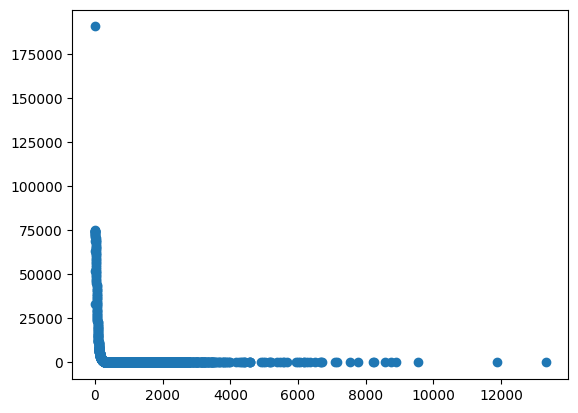

In [34]:
# 然后这里要将字典形式的计数转成列表形式的
lst_counts = [(key, dict_counts[key]) for key in dict_counts] 
# 这里进行排序
lst_counts.sort(key=lambda x:x[0])
# 然后这里绘制折线图吧
x = [x[0] for x in lst_counts]
y = [x[1] for x in lst_counts]
plt.scatter(x,y)